In [1]:
import time
import matplotlib.pyplot as plt
import tiktoken
import torch
import torch.nn as nn

In [2]:
from pathlib import Path
import importlib.util
import sys

optimization_root = Path.cwd().resolve().parent
if str(optimization_root) not in sys.path:
    sys.path.insert(0, str(optimization_root))

from Transformer_arquitectures import GPTModel as CachedGPTModel
from help_functions import generate_text_simple_cached, generate_text_simple

# Load the Foundation Model architecture without modifying its files.
foundation_root = optimization_root.parent / 'Foundation Model'
foundation_spec = importlib.util.spec_from_file_location(
    'foundation_transformer_architectures',
    foundation_root / 'Transformer_arquitectures.py',
)
foundation_module = importlib.util.module_from_spec(foundation_spec)
foundation_spec.loader.exec_module(foundation_module)
FoundationGPTModel = foundation_module.GPTModel

In [3]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [4]:
torch.manual_seed(42)

model = CachedGPTModel(GPT_CONFIG_124M)

model.eval() # Disable dropout and grads

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm()
  (out_head): Linear(in_features=768, out_features=50257

In [5]:
start_context = "Hello, I am"

tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)


In [6]:
print(f"\n{50*'='}\n{22*' '}IN\n{50*'='}")
print("\nInput text:", start_context)
print("Encoded input text:", encoded)
print("encoded_tensor.shape:", encoded_tensor.shape)


                      IN

Input text: Hello, I am
Encoded input text: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [7]:
if torch.cuda.is_available():
    torch.cuda.synchronize()
start = time.time()

# token_ids = generate_text_simple(
#     model=model,
#     idx=encoded_tensor,
#     max_new_tokens=200,
#     context_size=GPT_CONFIG_124M["context_length"]
# )

####################################################
# NEW
token_ids = generate_text_simple_cached(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=200,
)
####################################################

if torch.cuda.is_available():
    torch.cuda.synchronize()
total_time = time.time() - start

decoded_text = tokenizer.decode(token_ids.squeeze(0).tolist())

print(f"\n\n{50*'='}\n{22*' '}OUT\n{50*'='}")
print("\nOutput:", token_ids)
print("Output length:", len(token_ids[0]))
print("Output text:", decoded_text)

print(f"\nTime: {total_time:.2f} sec")
print(f"{int(len(token_ids[0])/total_time)} tokens/sec")
if torch.cuda.is_available():
    max_mem_bytes = torch.cuda.max_memory_allocated()
    max_mem_gb = max_mem_bytes / (1024 ** 3)
    print(f"Max memory allocated: {max_mem_gb:.2f} GB")




                      OUT

Output: tensor([[15496,    11,   314,   716,  4754, 22091, 43072, 19101, 14187, 41501,
          3336, 40410,  6486, 21546, 31516, 28448,  4925,  8396, 29711, 36311,
         41874, 13502, 49899, 37498, 17577, 24657, 40059, 39382, 21305, 20191,
         44176, 24019, 44611,  8615, 28690, 10383, 16777, 18683, 34687, 26119,
         43947, 20089, 11227, 38535, 22771, 16270, 38251, 12188, 25348, 14143,
         43616, 27338, 39897, 38403, 17611, 38109, 19820, 24633,  6200, 32803,
         34543, 12589, 31080, 27542, 21162, 46697, 41373, 17973,  7041,  5021,
           146, 11669, 14303,  3375,  6906, 15448, 21104, 44316, 25384, 19840,
         47715, 40967, 34664, 40882, 10992, 38126, 46910, 35269, 38355, 29876,
         31277, 31557,  4875, 47153, 12019,  5953, 48182, 24707, 33578, 32248,
         42429,   564,  5872,  3473,  1055, 41171, 14385, 49471, 11039, 42005,
         35077, 44860, 16672,  1939,  1845, 12879, 45088, 11855, 35289,  2998,
         25827,

In [8]:
# Fair comparison: identical configuration, prompt and number of generated tokens.
MAX_NEW_TOKENS = 200


def synchronize_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elif torch.backends.mps.is_available():
        torch.mps.synchronize()


def benchmark_generation(label, model, generate_tokens):
    model.eval()
    synchronize_device()
    start = time.perf_counter()
    token_ids = generate_tokens(model)
    synchronize_device()
    elapsed = time.perf_counter() - start
    generated_tokens = token_ids.shape[1] - encoded_tensor.shape[1]
    tokens_per_second = generated_tokens / elapsed
    print(f'{label}: {elapsed:.2f} s | {tokens_per_second:.2f} tokens/s')
    return elapsed, tokens_per_second


# Both models start from the same seed so their initialization is comparable.
torch.manual_seed(42)
cached_model = CachedGPTModel(GPT_CONFIG_124M)
cached_time, cached_speed = benchmark_generation(
    'KV-cache',
    cached_model,
    lambda model: generate_text_simple_cached(
        model=model, idx=encoded_tensor, max_new_tokens=MAX_NEW_TOKENS,
        context_size=GPT_CONFIG_124M['context_length'], use_cache=True,
    ),
)

del cached_model

torch.manual_seed(42)
foundation_model = FoundationGPTModel(GPT_CONFIG_124M)
foundation_time, foundation_speed = benchmark_generation(
    'Foundation Model (sin KV-cache)',
    foundation_model,
    lambda model: generate_text_simple(
        model=model, idx=encoded_tensor, max_new_tokens=MAX_NEW_TOKENS,
        context_size=GPT_CONFIG_124M['context_length'],
    ),
)

speedup = cached_speed / foundation_speed
time_reduction = 100 * (1 - cached_time / foundation_time)
print(f'\nAceleración del KV-cache: {speedup:.2f}x')
print(f'Reducción de tiempo: {time_reduction:.1f}%')

KV-cache: 2.19 s | 91.15 tokens/s
Foundation Model (sin KV-cache): 9.43 s | 21.21 tokens/s

Aceleración del KV-cache: 4.30x
Reducción de tiempo: 76.7%


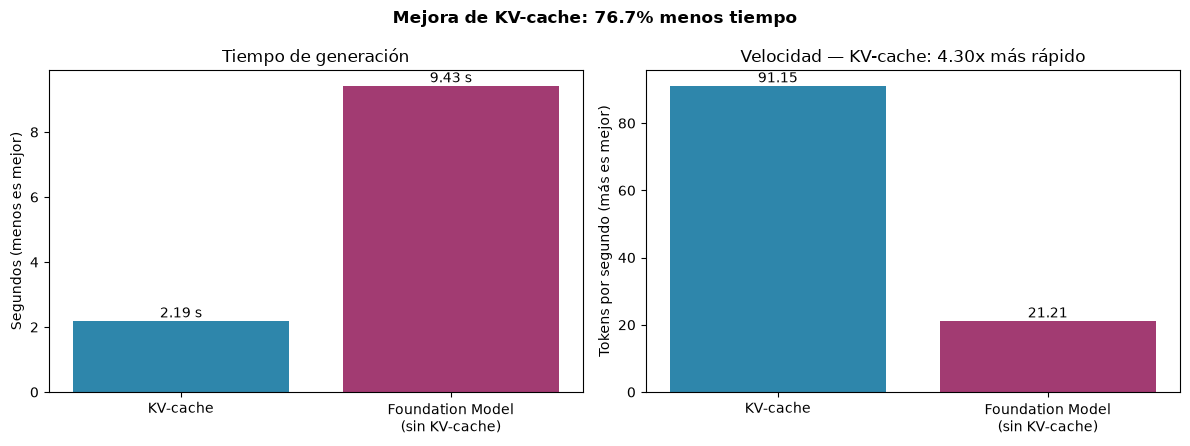

In [11]:
# Histograma comparativo de las mejoras de KV-cache.
labels = ['KV-cache', 'Foundation Model\n(sin KV-cache)']
colors = ['#2E86AB', '#A23B72']

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

times = [cached_time, foundation_time]
time_bars = axes[0].bar(labels, times, color=colors)
axes[0].set_title('Tiempo de generación')
axes[0].set_ylabel('Segundos (menos es mejor)')
axes[0].bar_label(time_bars, labels=[f'{value:.2f} s' for value in times])

speeds = [cached_speed, foundation_speed]
speed_bars = axes[1].bar(labels, speeds, color=colors)
axes[1].set_title(f'Velocidad — KV-cache: {speedup:.2f}x más rápido')
axes[1].set_ylabel('Tokens por segundo (más es mejor)')
axes[1].bar_label(speed_bars, labels=[f'{value:.2f}' for value in speeds])

figure.suptitle(f'Mejora de KV-cache: {time_reduction:.1f}% menos tiempo', fontweight='bold')
figure.tight_layout()
plt.savefig('kv_cache_benchmark.png', dpi=300)
plt.show()